In [2]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import functools as ft
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import svm
from PIL import Image
from pandas.plotting import scatter_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.decomposition import PCA
from pylab import rcParams
import matplotlib.pyplot as plt
#from google.colab import drive


In [3]:
def plot_confusion(prediction, target):
    '''
    plot correlation's matrix to explore dependency between features
    '''
    # list_labels_cat = ['ARTEFACTS', 'BLASTES', 'ERYTHROBLASTES', 'LYMPHOCYTES', 'MONOCYTES', 'MYELOCYTES', 'NEUTROPHILES']
    list_labels_cat = ['ARTEFACTS', 'BASOPHILES', 'BLASTES', 'EOSINOPHILES',
       'ERYTHROBLASTES', 'LYMPHOCYTES', 'METAMYELOCYTES', 'MONOCYTES',
       'MYELOCYTES', 'NEUTROPHILES', 'PROMYELOCYTES']
    # init figure size
    # targ_valids_cat = [list_labels_cat[i] for i in target]
    # preds_valids_cat = [list_labels_cat[i] for i in prediction]
    rcParams['figure.figsize'] = 7, 7
    df = pd.DataFrame(confusion_matrix(target, prediction, labels = list_labels_cat, normalize = 'true'), index = list_labels_cat, columns= list_labels_cat)
    # df = pd.DataFrame(confusion_matrix(targ_valids_cat, preds_valids_cat, labels = list_labels_cat, normalize = 'true'))

    fig = plt.figure()
    sns.heatmap(df, annot=True, fmt=".2f")
    plt.show()
    fig.savefig('corr.png')


# Import features

In [4]:
features_table = pd.read_csv('features_table_renamed_features.csv')
len(features_table.columns)

42

In [5]:
features_table.head()

,Unnamed: 0,cytoID,Hematoxylin_Mean_nuclei,Hematoxylin_Std_dev_nuclei,Hematoxylin_Min_nuclei,Hematoxylin_Max_nuclei,Hematoxylin_Median_nuclei,Eosin_Mean_nuclei,Eosin_Std_dev_nuclei,Eosin_Min_nuclei,...,Eosin_Min_cytoonly,Eosin_Max_cytoonly,Hue_Mean_cytoonly,Saturation_Mean_cytoonly,Saturation_Std_dev_cytoonly,Saturation_Min_cytoonly,Saturation_Max_cytoonly,Saturation_Median_cytoonly,Eosin_Median_cytoonly,Area_µm^2_cytoonly
0,0,837,0.3095,0.0945,0.0600,0.6984,0.3025,0.2581,0.1013,0.0578,...,-0.0108,0.9250,0.2995,0.0803,0.1068,0.0,0.9489,0.0335,0.0275,580.8835
1,1,447,0.3790,0.1280,0.0738,0.8538,0.3595,0.3362,0.2064,0.0346,...,0.0053,1.5916,0.3480,0.2224,0.0871,0.0,1.0000,0.2375,0.1405,336.1428
2,2,435,0.4304,0.1727,0.0384,1.0462,0.4145,0.4348,0.3306,0.0145,...,-0.0075,1.6237,0.3540,0.2508,0.0988,0.0,1.0000,0.2455,0.1545,295.5429
3,3,737,0.3011,0.1867,0.0271,1.3582,0.2535,0.2454,0.2487,-0.0462,...,-0.0287,1.6220,0.3327,0.3251,0.1391,0.0,1.0000,0.2905,0.1805,176.0093
4,4,176,0.3344,0.1360,0.0294,0.8590,0.3345,0.3085,0.1938,0.0077,...,-0.0013,0.6878,0.3425,0.2027,0.0729,0.0,0.8716,0.2135,0.0965,264.4129


# Find null values

1) List the number of null values for each column. Which column has nan values?


2) Delete the rows where there are nan values


In [6]:
# Listing the number of zeros in each column
zeros = []
for col in features_table.columns:
    zeros.append((features_table[col] == 0).sum())
zeros_df = pd.DataFrame({'feature': features_table.columns, 'zeros': zeros})
zeros_df

,feature,zeros
0,Unnamed: 0,2
1,cytoID,0
2,Hematoxylin_Mean_nuclei,0
3,Hematoxylin_Std_dev_nuclei,0
4,Hematoxylin_Min_nuclei,1
5,Hematoxylin_Max_nuclei,0
6,Hematoxylin_Median_nuclei,0
7,Eosin_Mean_nuclei,0
8,Eosin_Std_dev_nuclei,0
9,Eosin_Min_nuclei,0


In [7]:
# Finding the NaNs 
for col in features_table.columns:
    nans_count = features_table[col].isna().sum()
    if nans_count > 0:
        print(f"Column '{col}' has {nans_count} NaN values.")

Column 'Circularity_cyto' has 29 NaN values.


In [8]:
# Deleting the rows with NaN values
features_table = features_table.dropna()
features_table.isna().sum()

Unnamed: 0                      0
cytoID                          0
Hematoxylin_Mean_nuclei         0
Hematoxylin_Std_dev_nuclei      0
Hematoxylin_Min_nuclei          0
Hematoxylin_Max_nuclei          0
Hematoxylin_Median_nuclei       0
Eosin_Mean_nuclei               0
Eosin_Std_dev_nuclei            0
Eosin_Min_nuclei                0
Eosin_Max_nuclei                0
Hue_Mean_nuclei                 0
Saturation_Mean_nuclei          0
Saturation_Std_dev_nuclei       0
Saturation_Min_nuclei           0
Saturation_Max_nuclei           0
Saturation_Median_nuclei        0
Eosin_Median_nuclei             0
Area_µm^2_nuclei                0
Length_µm_cyto                  0
Circularity_cyto                0
Solidity_cyto                   0
Max_diameter_µm_cyto            0
Min_diameter_µm_cyto            0
Perimeter_µm_cyto               0
Hematoxylin_Mean_cytoonly       0
Hematoxylin_Std_dev_cytoonly    0
Hematoxylin_Min_cytoonly        0
Hematoxylin_Max_cytoonly        0
Hematoxylin_Me

# Add labels

In [9]:
labels = pd.read_csv('labels.csv')
labels

,Unnamed: 0,cytoID,label
0,0,628,NEUTROPHILES
1,1,468,NEUTROPHILES
2,2,55,NEUTROPHILES
3,3,464,NEUTROPHILES
4,4,541,BLASTES
...,...,...,...
3135,2012,2561,LYMPHOCYTES
3136,2013,2829,ERYTHROBLASTES
3137,2014,2591,NEUTROPHILES
3138,2015,2849,ERYTHROBLASTES


3) We want to remove the labels of the cells deleted in the previous question. To do so, create a new dataframe "*dataset*" generated by the joint of *features_table* and *labels* on **cytoID** number.

In [10]:
dataset = features_table.merge(labels, left_on= 'cytoID', right_on= 'cytoID')

In [11]:
dataset = dataset.dropna()

# Visualise the distribution of the class



4) Count the number of cells per class. What can we say about the distribution of the classes?

5) Plot the distribution of the classes using sns.countplot() and the dataframe.

*Expected result*

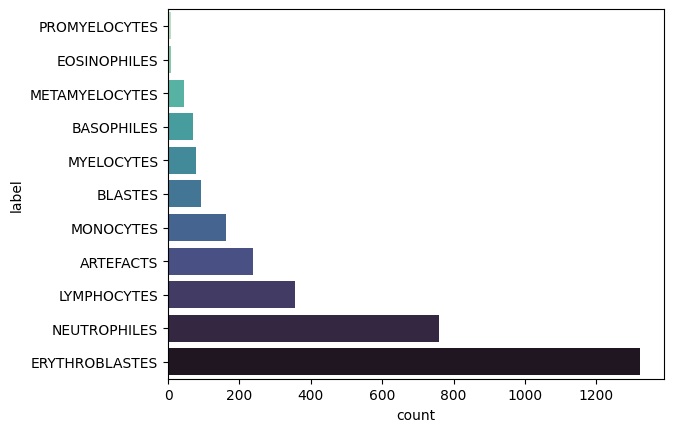

In [12]:
# Number of cells per class
dataset['label'].value_counts()

label
ERYTHROBLASTES    1320
NEUTROPHILES       749
LYMPHOCYTES        357
ARTEFACTS          231
MONOCYTES          160
BLASTES             91
MYELOCYTES          77
BASOPHILES          68
METAMYELOCYTES      44
EOSINOPHILES         7
PROMYELOCYTES        6
Name: count, dtype: int64

As we can see, the distribution is really unbalanced. Some classes are largely under represented. 

/var/folders/0f/6c8rjvls46g5vw3zh6l1137w0000gn/T/ipykernel_27387/1504115470.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='label', data=dataset, order=dataset['label'].value_counts().index, palette='Set1')


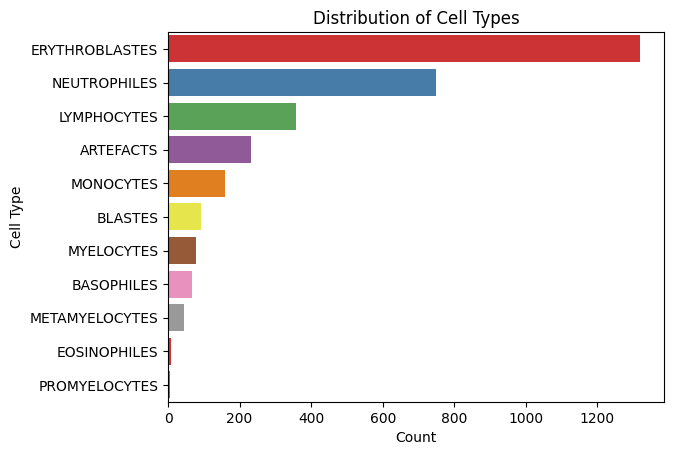

In [13]:
sns.countplot(y='label', data=dataset, order=dataset['label'].value_counts().index, palette='Set1')
plt.title('Distribution of Cell Types')
plt.ylabel('Cell Type')
plt.xlabel('Count')
plt.show()

# Visualise features

We can use .describe() to visualise the behaviour of each feature.

In [14]:
dataset.describe()

,Unnamed: 0_x,cytoID,Hematoxylin_Mean_nuclei,Hematoxylin_Std_dev_nuclei,Hematoxylin_Min_nuclei,Hematoxylin_Max_nuclei,Hematoxylin_Median_nuclei,Eosin_Mean_nuclei,Eosin_Std_dev_nuclei,Eosin_Min_nuclei,...,Eosin_Max_cytoonly,Hue_Mean_cytoonly,Saturation_Mean_cytoonly,Saturation_Std_dev_cytoonly,Saturation_Min_cytoonly,Saturation_Max_cytoonly,Saturation_Median_cytoonly,Eosin_Median_cytoonly,Area_µm^2_cytoonly,Unnamed: 0_y
count,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,...,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000,3110.000000
mean,850.220900,1574.875241,0.863911,0.242266,0.151510,1.767968,0.864445,0.226423,0.237001,-0.271824,...,0.975739,0.241823,0.258577,0.148072,0.022247,0.895672,0.227580,0.044030,51.556067,847.837299
std,548.072579,906.189013,0.641885,0.162756,0.139328,1.195020,0.647994,0.166961,0.120402,0.459606,...,0.522370,0.059630,0.101322,0.063019,0.033845,0.168434,0.095092,0.046182,55.102101,549.702719
min,0.000000,1.000000,0.136200,0.033600,-0.049300,0.276500,0.073500,-0.734400,0.011200,-1.943500,...,-0.026800,0.131100,0.044500,0.029800,0.000000,0.233300,0.021500,0.000000,0.511500,0.000000
25%,394.250000,790.250000,0.354775,0.117500,0.047750,0.861900,0.344500,0.122150,0.131950,-0.261100,...,0.454475,0.189450,0.189400,0.098900,0.000000,0.841075,0.165750,0.000000,12.195700,391.000000
50%,787.000000,1577.500000,0.577000,0.186700,0.105150,1.273900,0.559500,0.221650,0.239900,-0.083050,...,1.119400,0.239900,0.237550,0.134550,0.008500,1.000000,0.212500,0.033500,26.240350,783.500000
75%,1233.750000,2358.750000,1.258450,0.324700,0.218575,2.319775,1.299250,0.315475,0.332725,0.002475,...,1.395700,0.297050,0.311675,0.188175,0.028450,1.000000,0.273500,0.075500,79.882625,1234.750000
max,2015.000000,3140.000000,3.193700,0.996000,1.147000,4.278200,3.139500,0.911500,0.684200,0.179200,...,3.855600,0.477700,0.791600,0.367300,0.328700,1.000000,0.962500,0.692500,580.883500,2016.000000


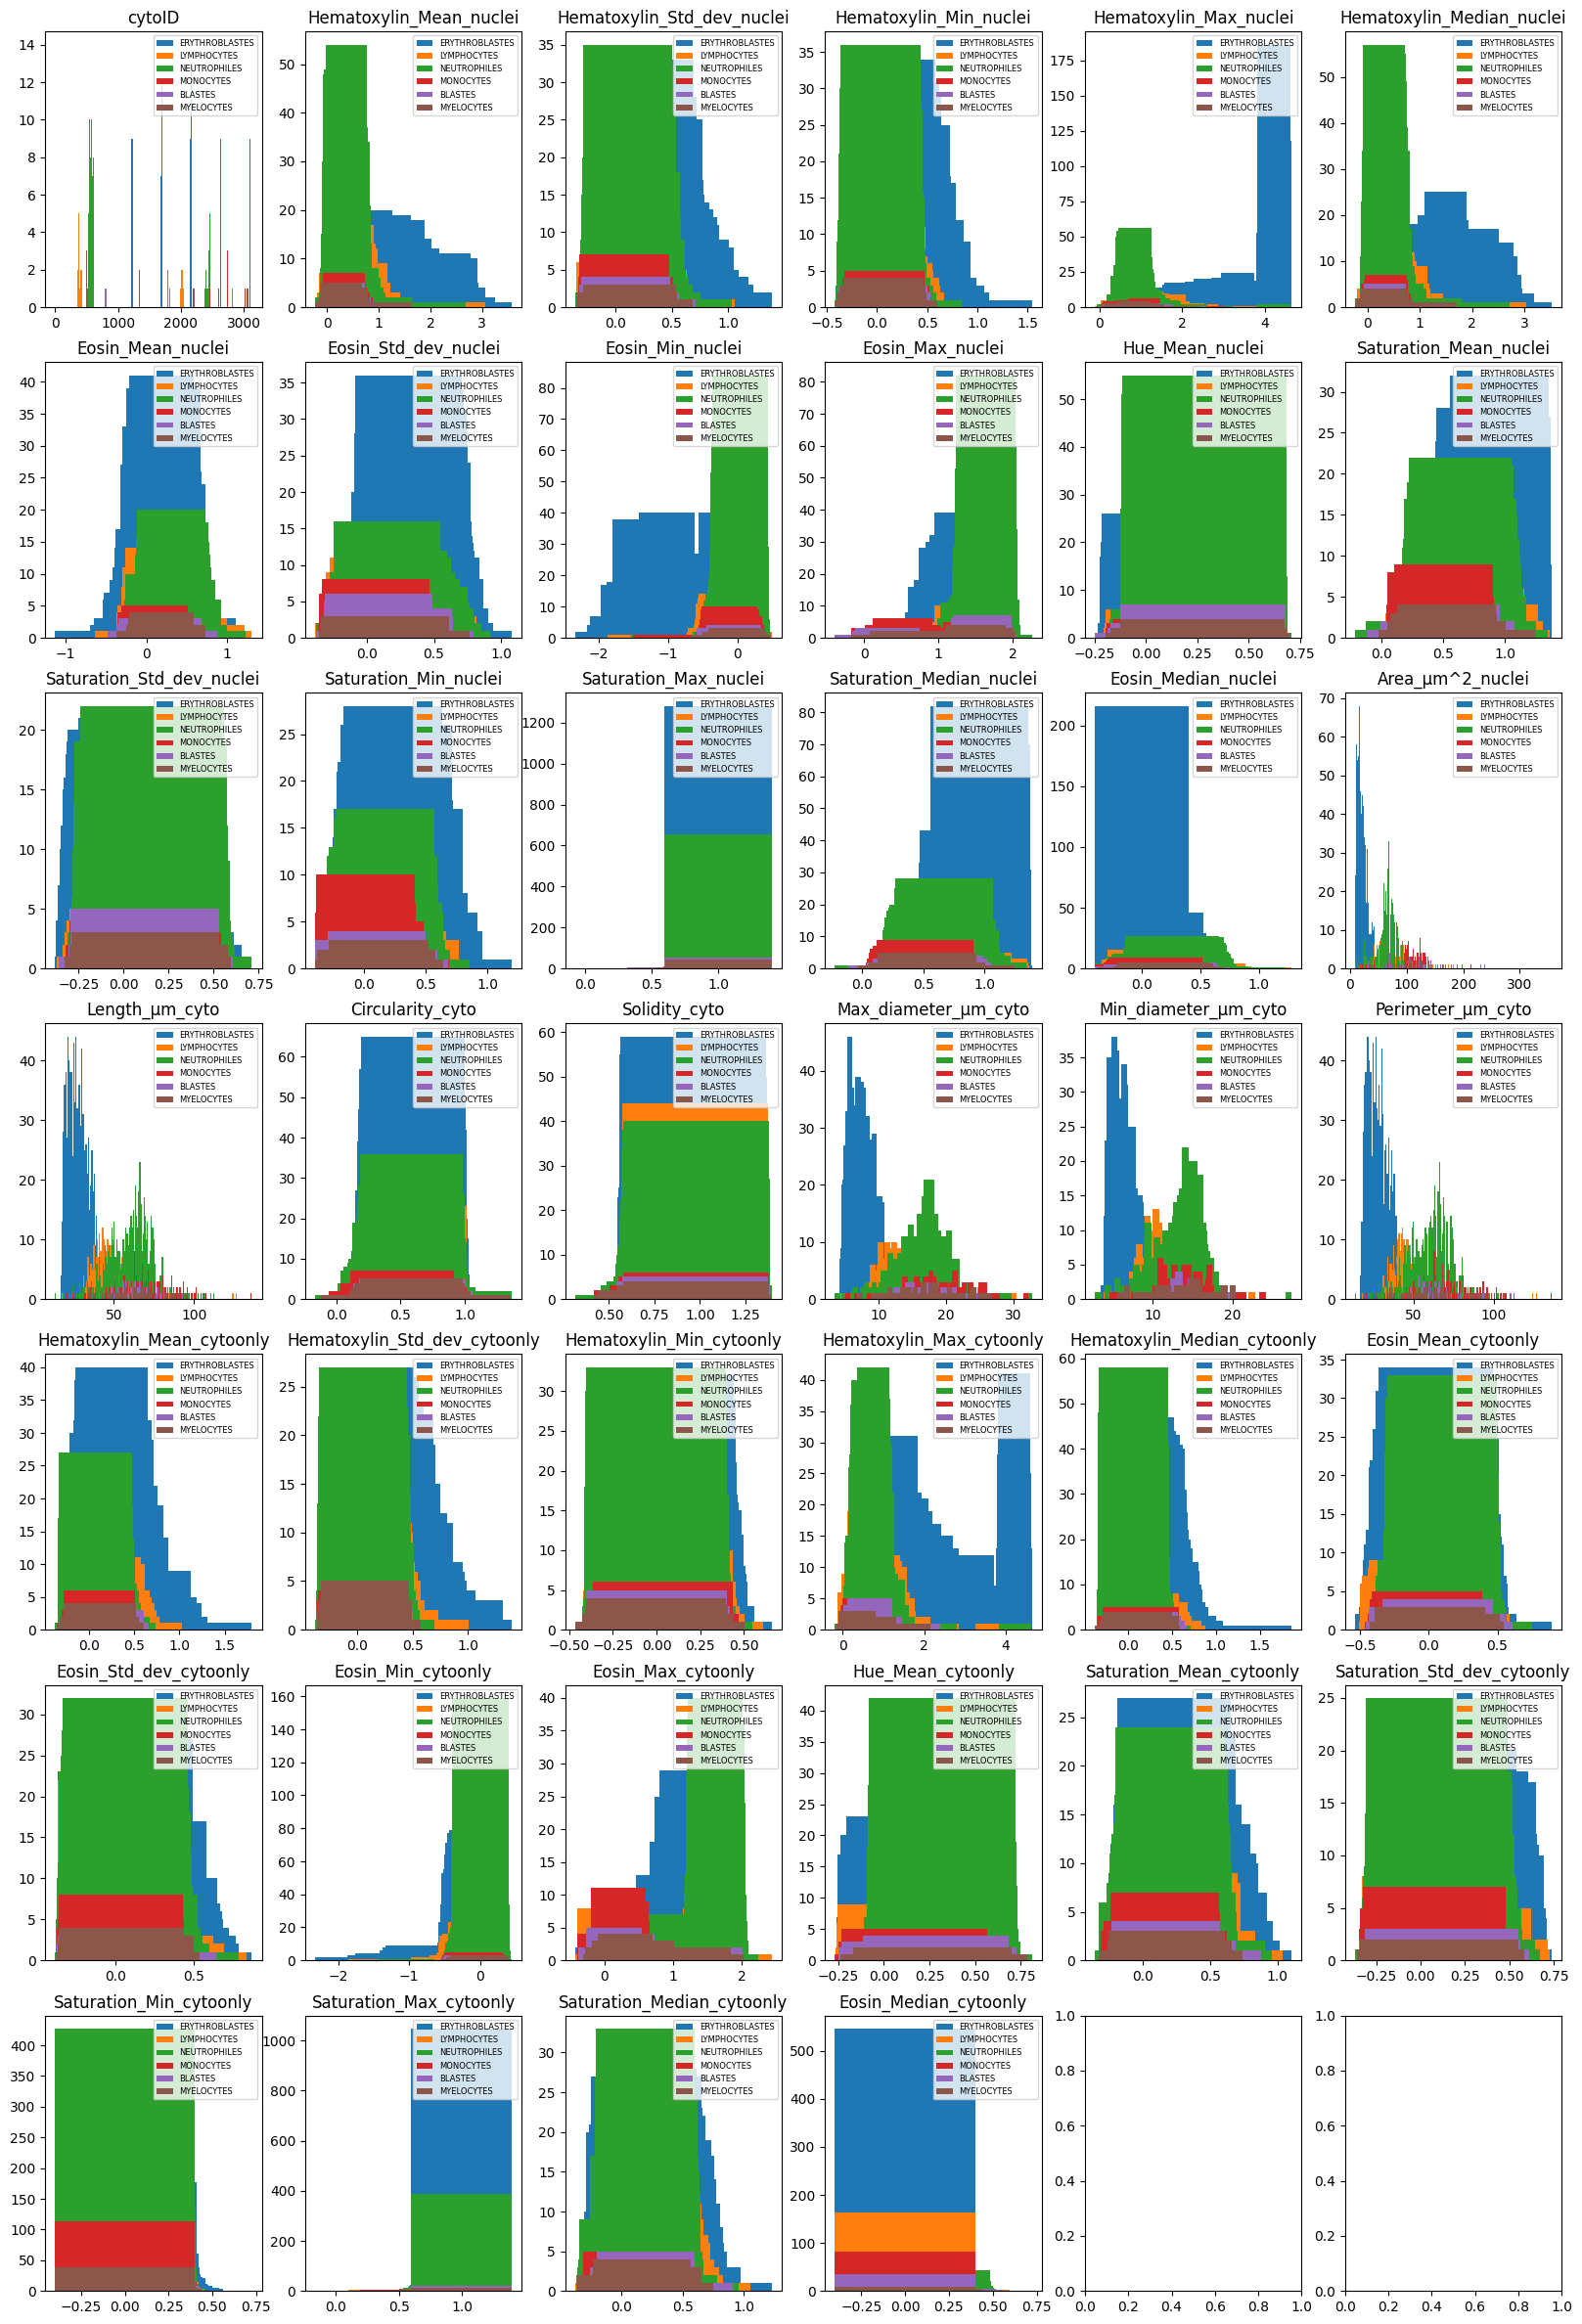

In [15]:
rcParams['figure.figsize'] = 20, 30
fig, axes = plt.subplots(7,6)

for i, ax in enumerate(axes.flat, start=1):
    if i < 41:
        y_max = 0
        for k in ['ERYTHROBLASTES', 'LYMPHOCYTES','NEUTROPHILES', 'MONOCYTES',  'BLASTES', 'MYELOCYTES']:

            sub_df = dataset.loc[dataset.label == k]

            sub_df =sub_df.drop('label', axis = 1)
            a_heights, a_bins = np.histogram(np.array(sub_df[dataset.columns[i]], dtype=float), bins=200)
            if max(a_heights) + max(a_heights)*0.05 > y_max:
                y_max = max(a_heights) + max(a_heights)*0.05

            ax.bar(a_bins[:-1], a_heights, label = k)
            ax.legend(loc="upper right", prop={'size': 6})
            ax.set_ylim((0, y_max))
            ax.set_xlabel = ('Feature value')
            ax.set_ylabel = ('Number of cells')
            ax.set_title(dataset.columns[i])


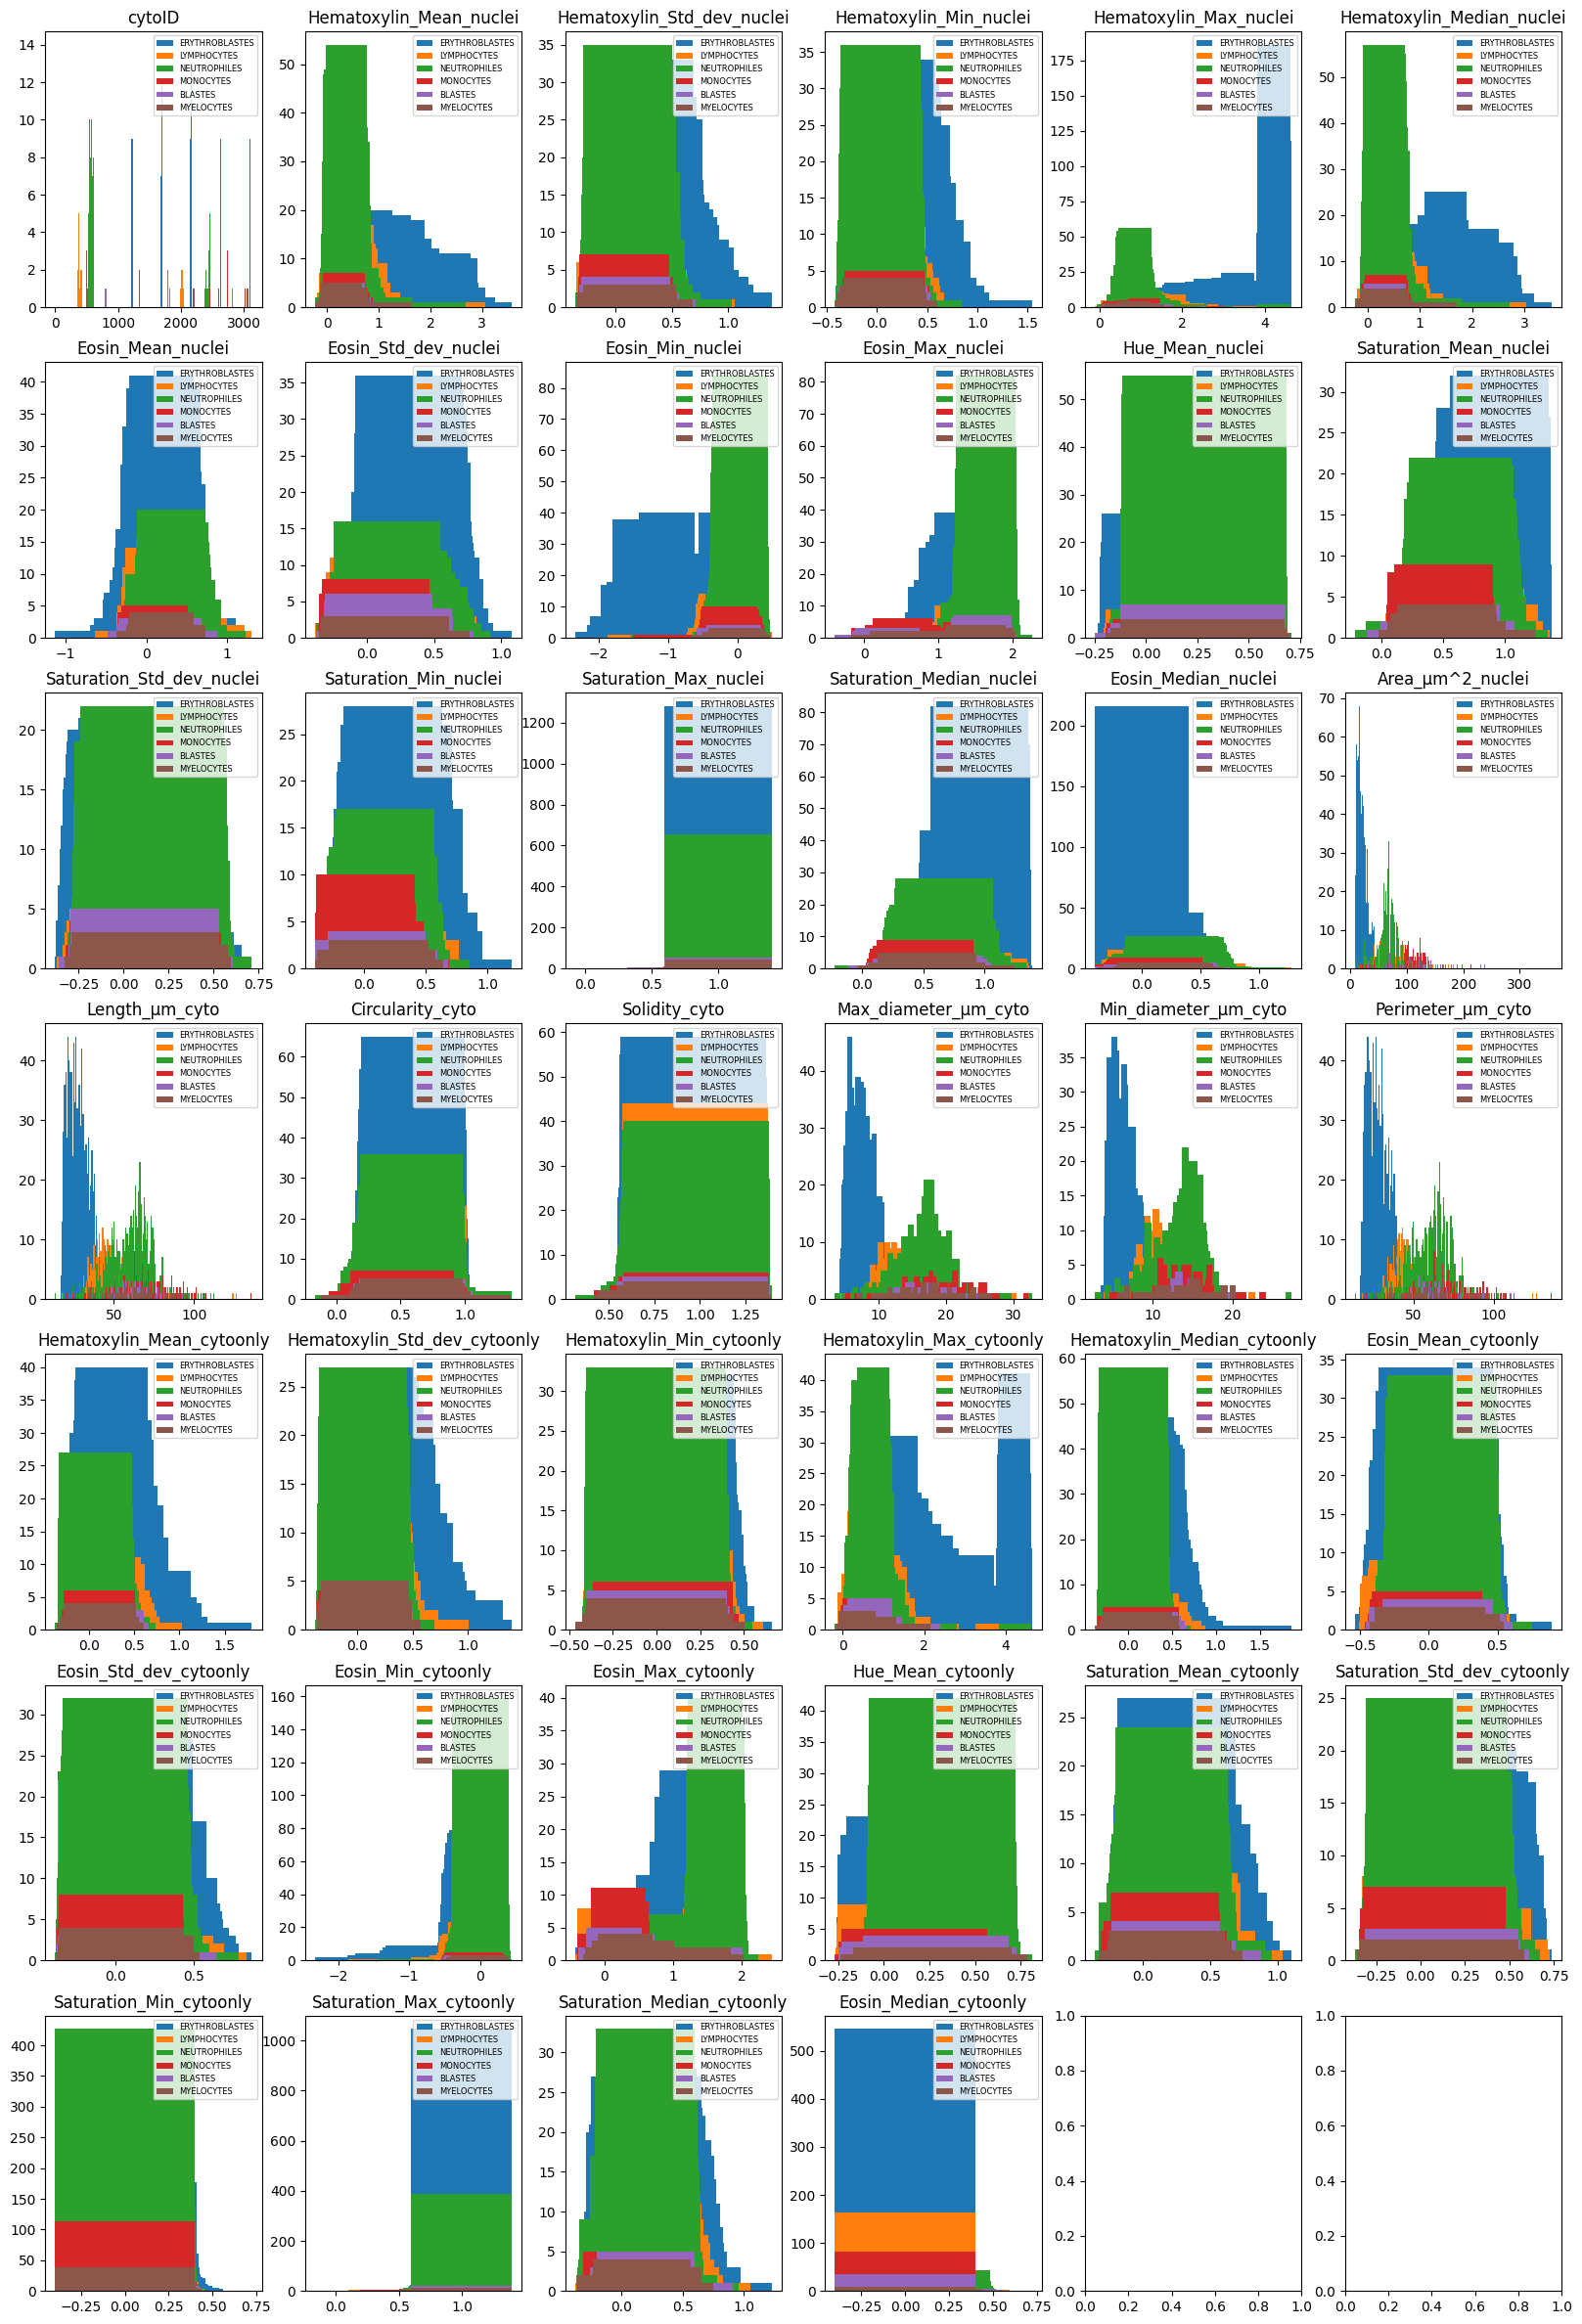

6) The above figure represents the distribution of cells according to features.

Which features do you think are the most discriminative for determining cell class? Explain.

The most discriminative features for determining cell classes are that have well spread and separated distributions. Observing the figures we can see that : 
- size and geometry features are very strong discriminator (area, perimeter, diameter)
- hematoxylin stats are strong discriminator as well 

7) a) Using scatter_matrix(), represent the correlation between 6 geometrical features.

b) Do the same for 6 colour features (preferably different colour features, ex: Eosin, Hematoxylin, Hue...)

*Expected result*

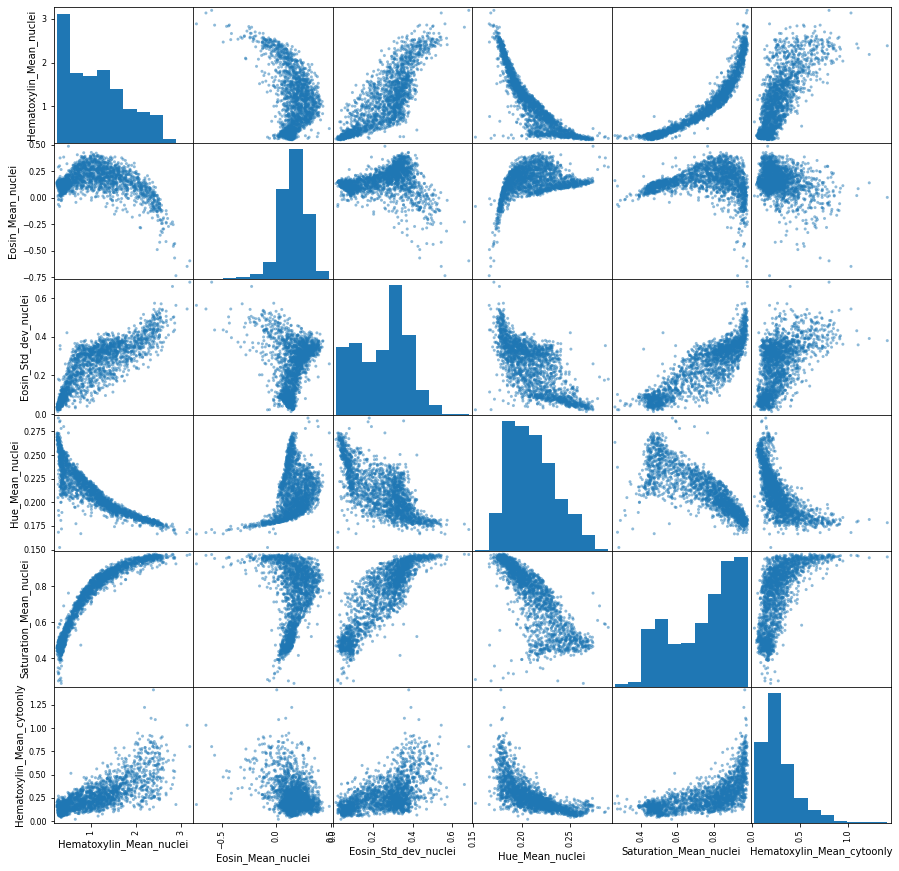


array([[<AxesSubplot:xlabel='Perimeter_µm_cyto', ylabel='Perimeter_µm_cyto'>,
        <AxesSubplot:xlabel='Max_diameter_µm_cyto', ylabel='Perimeter_µm_cyto'>,
        <AxesSubplot:xlabel='Min_diameter_µm_cyto', ylabel='Perimeter_µm_cyto'>,
        <AxesSubplot:xlabel='Area_µm^2_nuclei', ylabel='Perimeter_µm_cyto'>,
        <AxesSubplot:xlabel='Circularity_cyto', ylabel='Perimeter_µm_cyto'>,
        <AxesSubplot:xlabel='Area_µm^2_cytoonly', ylabel='Perimeter_µm_cyto'>],
       [<AxesSubplot:xlabel='Perimeter_µm_cyto', ylabel='Max_diameter_µm_cyto'>,
        <AxesSubplot:xlabel='Max_diameter_µm_cyto', ylabel='Max_diameter_µm_cyto'>,
        <AxesSubplot:xlabel='Min_diameter_µm_cyto', ylabel='Max_diameter_µm_cyto'>,
        <AxesSubplot:xlabel='Area_µm^2_nuclei', ylabel='Max_diameter_µm_cyto'>,
        <AxesSubplot:xlabel='Circularity_cyto', ylabel='Max_diameter_µm_cyto'>,
        <AxesSubplot:xlabel='Area_µm^2_cytoonly', ylabel='Max_diameter_µm_cyto'>],
       [<AxesSubplot:xlabel='Perim

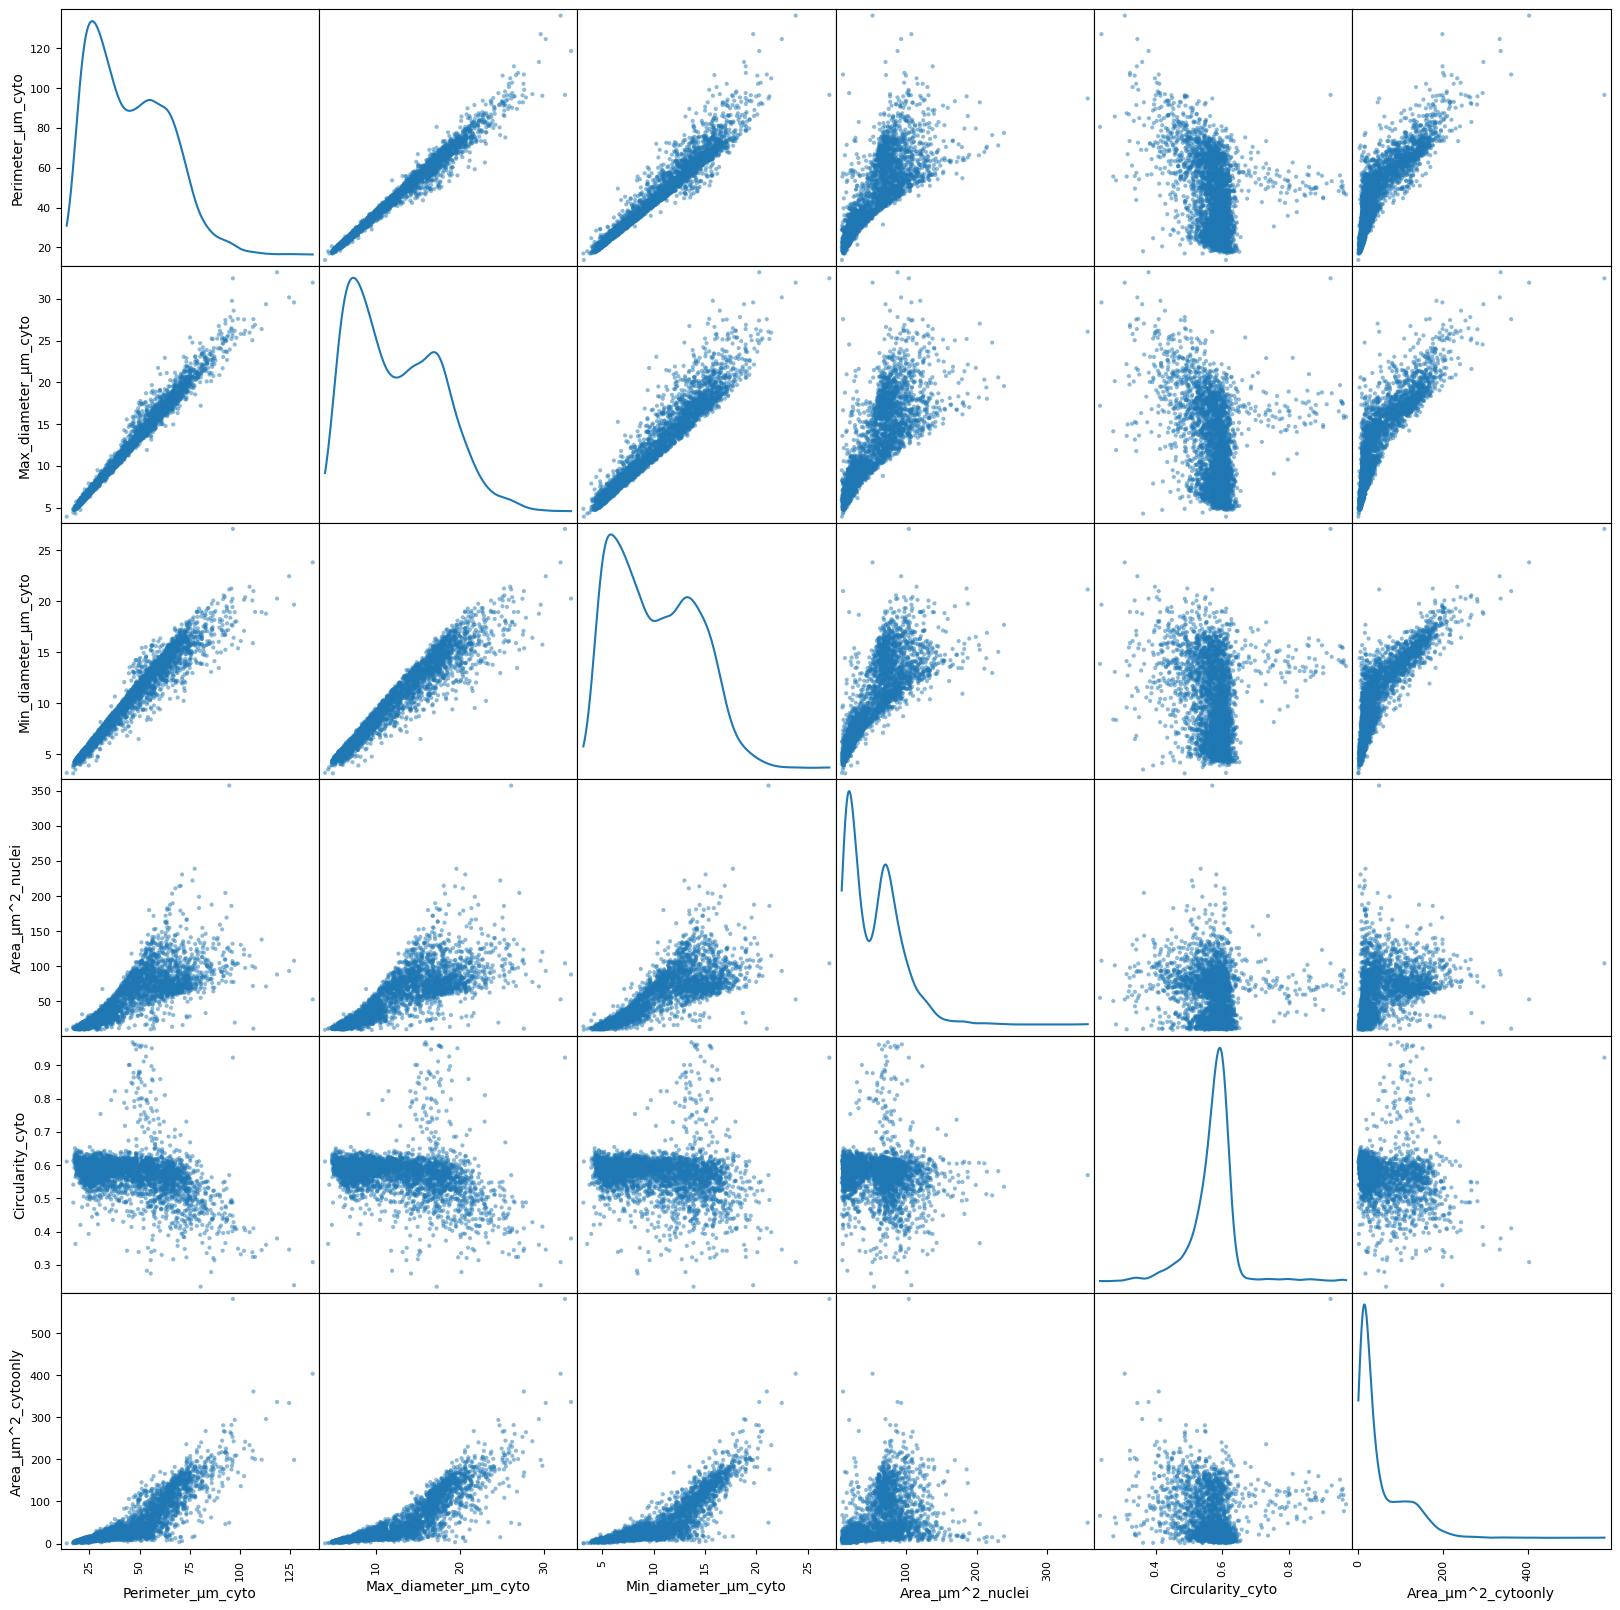

In [16]:
geometrical_features = ['Perimeter_µm_cyto', 'Max_diameter_µm_cyto', 'Min_diameter_µm_cyto', 'Area_µm^2_nuclei', 'Circularity_cyto', 'Area_µm^2_cytoonly']
scatter_matrix(dataset[geometrical_features], figsize=(20, 20), diagonal='kde')

array([[<AxesSubplot:xlabel='Eosin_Median_cytoonly', ylabel='Eosin_Median_cytoonly'>,
        <AxesSubplot:xlabel='Hematoxylin_Median_nuclei', ylabel='Eosin_Median_cytoonly'>,
        <AxesSubplot:xlabel='Hue_Mean_nuclei', ylabel='Eosin_Median_cytoonly'>,
        <AxesSubplot:xlabel='Saturation_Mean_nuclei', ylabel='Eosin_Median_cytoonly'>,
        <AxesSubplot:xlabel='Eosin_Median_nuclei', ylabel='Eosin_Median_cytoonly'>,
        <AxesSubplot:xlabel='Saturation_Median_cytoonly', ylabel='Eosin_Median_cytoonly'>],
       [<AxesSubplot:xlabel='Eosin_Median_cytoonly', ylabel='Hematoxylin_Median_nuclei'>,
        <AxesSubplot:xlabel='Hematoxylin_Median_nuclei', ylabel='Hematoxylin_Median_nuclei'>,
        <AxesSubplot:xlabel='Hue_Mean_nuclei', ylabel='Hematoxylin_Median_nuclei'>,
        <AxesSubplot:xlabel='Saturation_Mean_nuclei', ylabel='Hematoxylin_Median_nuclei'>,
        <AxesSubplot:xlabel='Eosin_Median_nuclei', ylabel='Hematoxylin_Median_nuclei'>,
        <AxesSubplot:xlabel='Satur

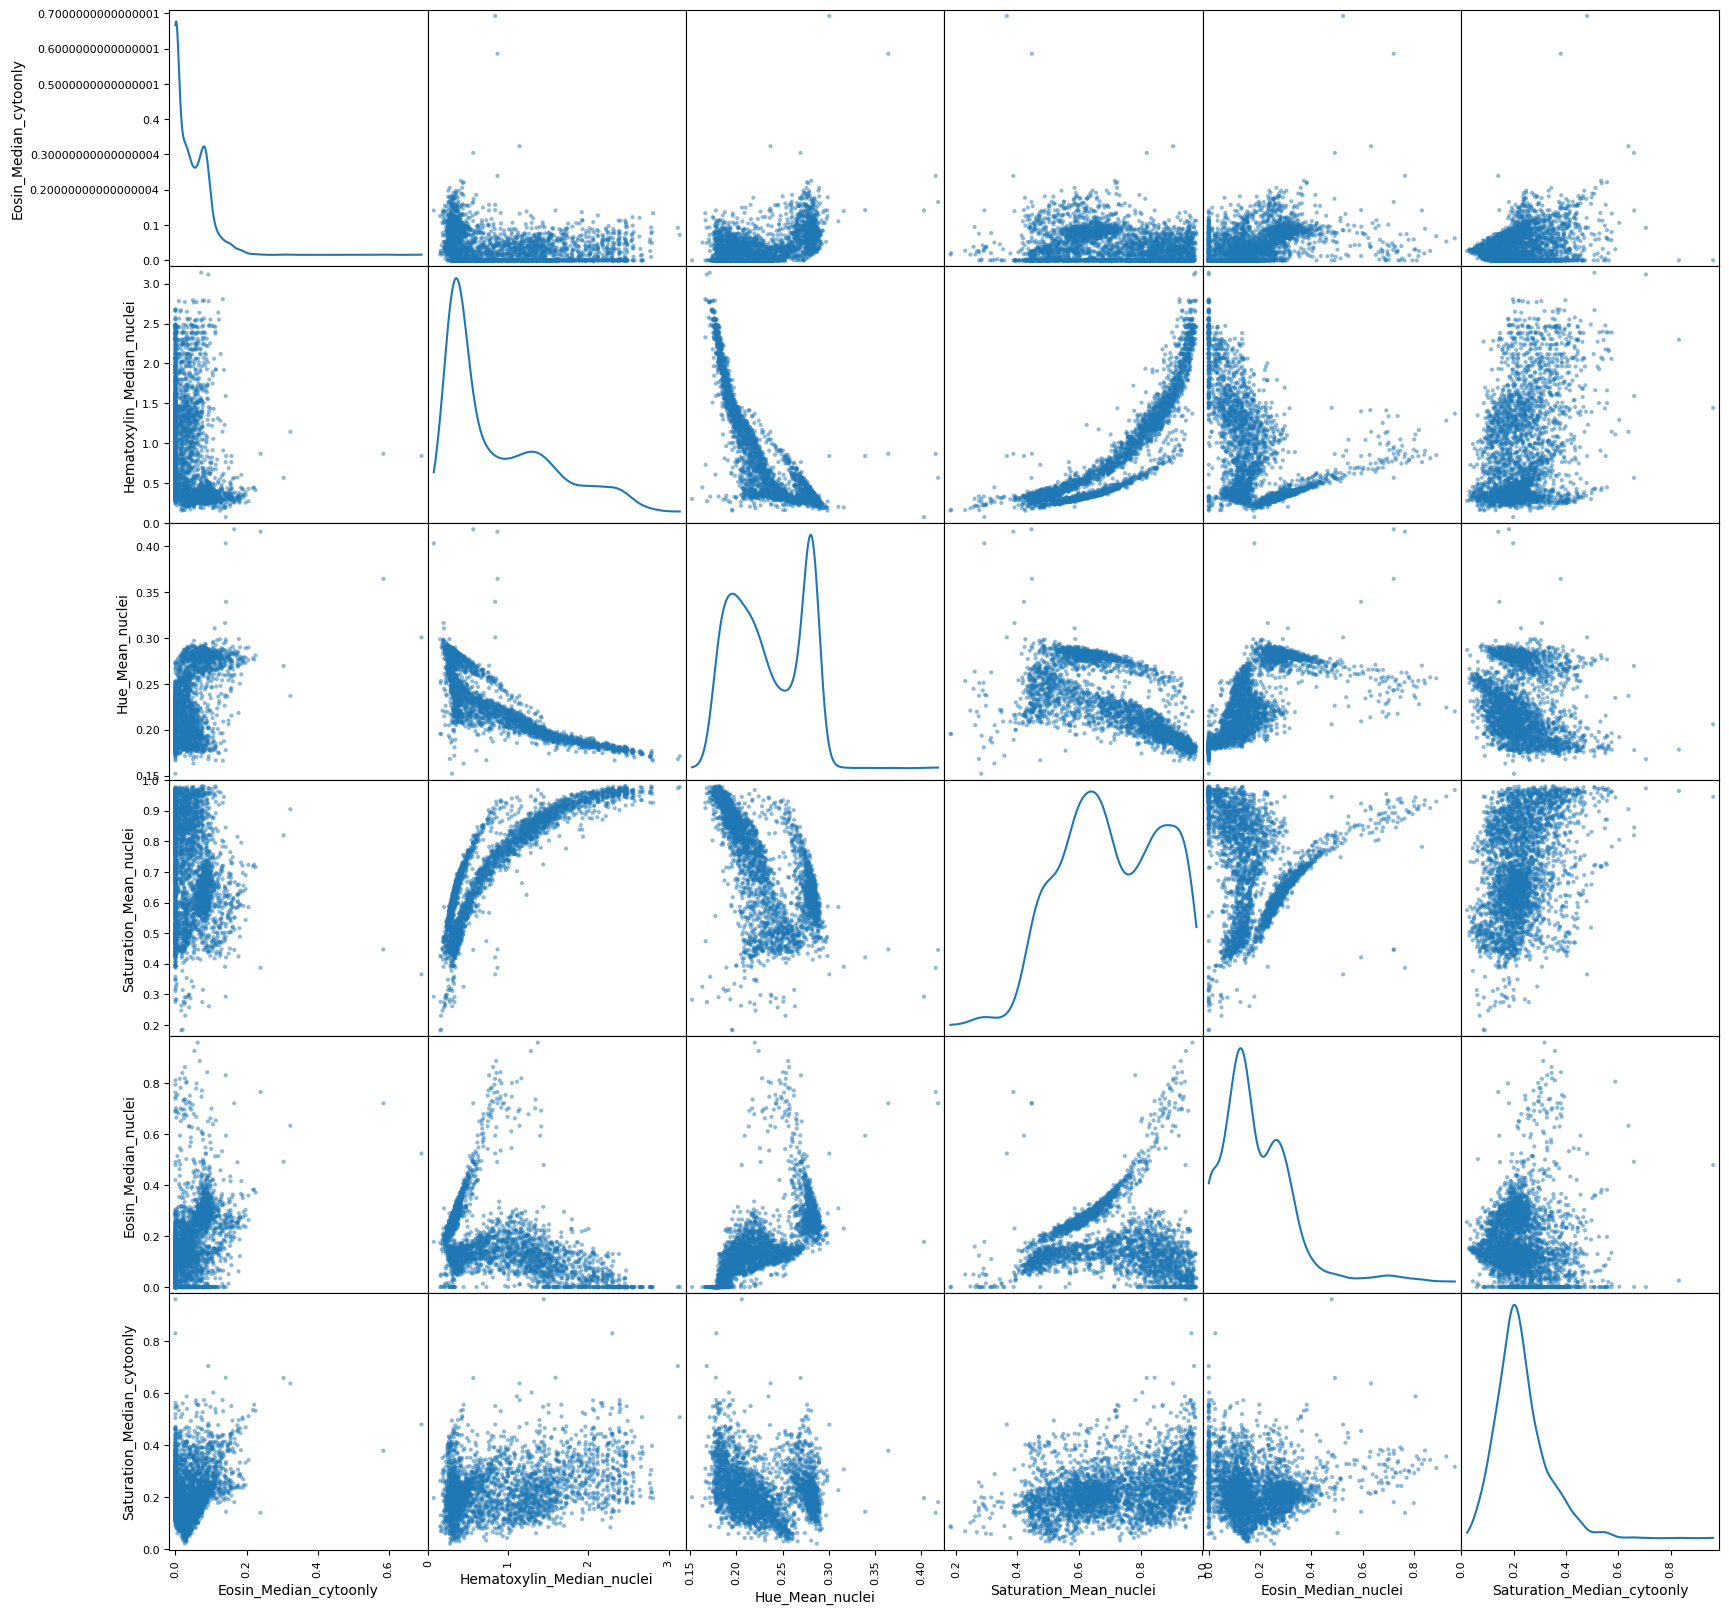

In [17]:
geometrical_features = ['Eosin_Median_cytoonly', 'Hematoxylin_Median_nuclei', 'Hue_Mean_nuclei', 'Saturation_Mean_nuclei', 'Eosin_Median_nuclei', 'Saturation_Median_cytoonly']
scatter_matrix(dataset[geometrical_features], figsize=(20, 20), diagonal='kde')

8) Represent the repartition of cells by class for two of the most discriminative features, using sns.boxplot.


*Expected result for a random selected feature*

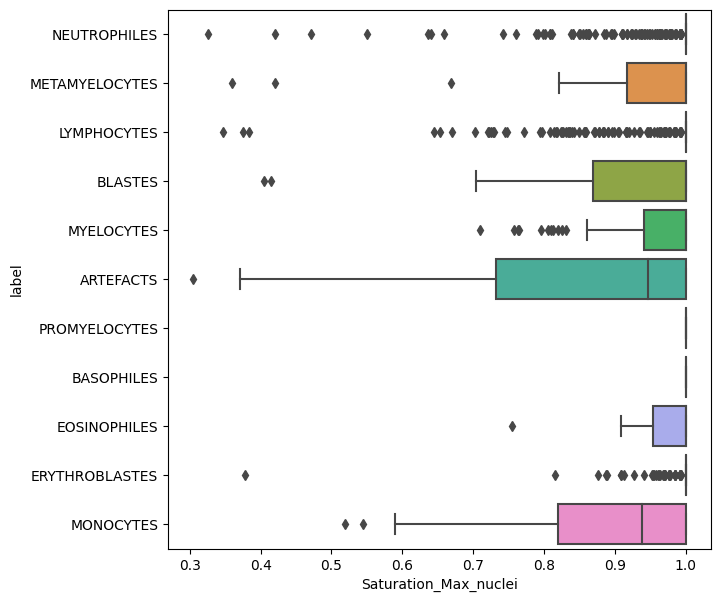

/var/folders/0f/6c8rjvls46g5vw3zh6l1137w0000gn/T/ipykernel_27387/1177553292.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=dataset, x='Perimeter_µm_cyto', y='label', orient='h', palette='Set1')


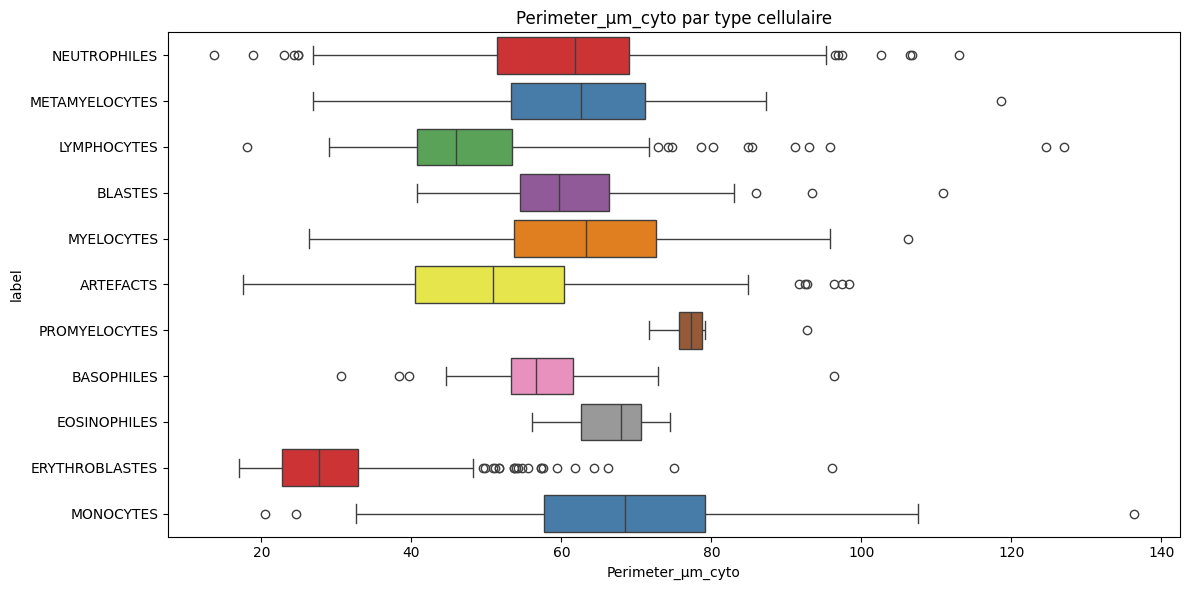

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=dataset, x='Perimeter_µm_cyto', y='label', orient='h', palette='Set1')
plt.title('Perimeter_µm_cyto par type cellulaire')
plt.xlabel('Perimeter_µm_cyto')
plt.ylabel('label')
plt.tight_layout()
plt.show()

# Create X and y



In [24]:
X = dataset.drop(['cytoID', 'label'], axis=1)
len(X)
y = dataset[['label']]
y

,label
0,NEUTROPHILES
1,METAMYELOCYTES
2,NEUTROPHILES
3,LYMPHOCYTES
4,NEUTROPHILES
...,...
3105,ERYTHROBLASTES
3106,ERYTHROBLASTES
3107,ERYTHROBLASTES
3108,ERYTHROBLASTES


# Splitting the dataset

*train_test_split* allows us to make the split, and makes sure the class distribution is the same in the train and the test as the initial distribution.

We decide to keep 20% of the data for the test with *test_size*.

*random_state* allows us to have the same random cut everytime we run the code, and thus to make the results repeatable.


In [25]:
X_train, X_test, y_train, y_test  = train_test_split(X, y, test_size= 0.2, random_state=42)

Remark: train_test_split keeps the distribution of classes
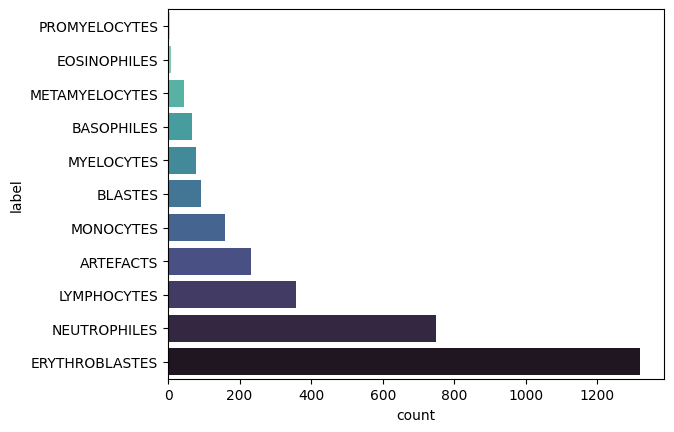


# Rescale data

9) Use *SandardScaler()* to rescale data in X_train.

Remark: the standardscaler is trained on X_train using *fit_transform*, and then applied on X_test using *transform*.

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training model

## SVM model

10) Train a SVM model on the training dataset. Use it to make prediction of the test dataset.


11) Evaluate your performance using *confusion_matrix* and *classification_report*.

You can use *plot_confusion* to visualise the normalised confusion matrix.

*Expected result*


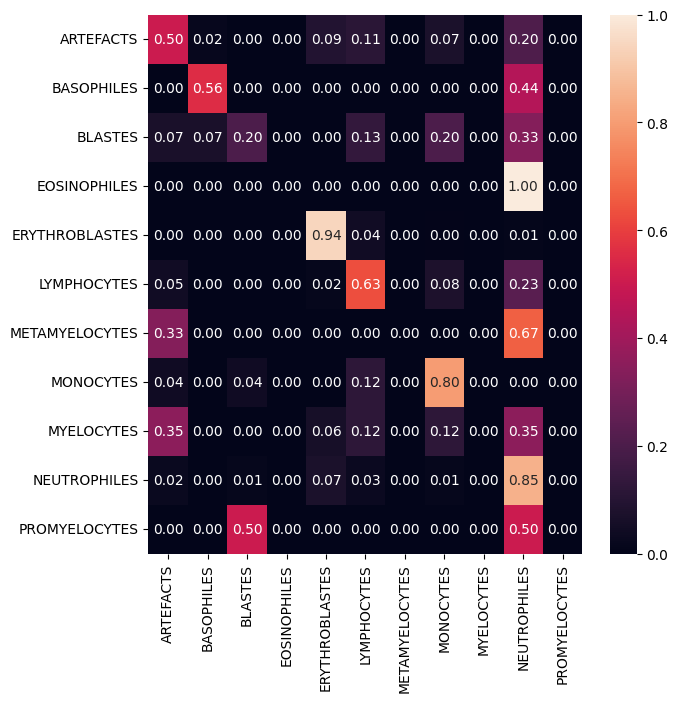

In [ ]:
svm_model = svm.SVC(kernel='rbf', gamma='scale')
svm_model.fit(X_train_scaled, y_train.values.ravel())

SVC(C=1)

SVM Accuracy: 0.770096463022508


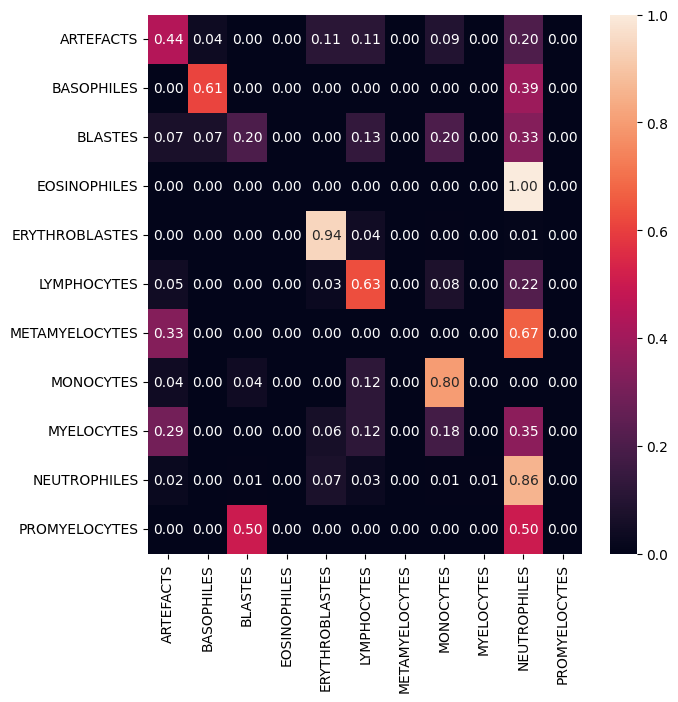

In [29]:
svm_preds = svm_model.predict(X_test_scaled)
print("SVM Accuracy:", accuracy_score(y_test, svm_preds))
plot_confusion(svm_preds, y_test.values.ravel())

In [32]:
report = classification_report(y_test, svm_preds)
print(report)

                precision    recall  f1-score   support

     ARTEFACTS       0.60      0.44      0.51        54
    BASOPHILES       0.79      0.61      0.69        18
       BLASTES       0.50      0.20      0.29        15
  EOSINOPHILES       0.00      0.00      0.00         2
ERYTHROBLASTES       0.92      0.94      0.93       250
   LYMPHOCYTES       0.59      0.63      0.61        65
METAMYELOCYTES       0.00      0.00      0.00         6
     MONOCYTES       0.53      0.80      0.63        25
    MYELOCYTES       0.00      0.00      0.00        17
  NEUTROPHILES       0.73      0.86      0.79       168
 PROMYELOCYTES       0.00      0.00      0.00         2

      accuracy                           0.77       622
     macro avg       0.42      0.41      0.40       622
  weighted avg       0.74      0.77      0.75       622



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

## Random Forest
13 )  Repeat 10) and 11) but with RandomForest model

Random Forest Accuracy: 0.7733118971061094


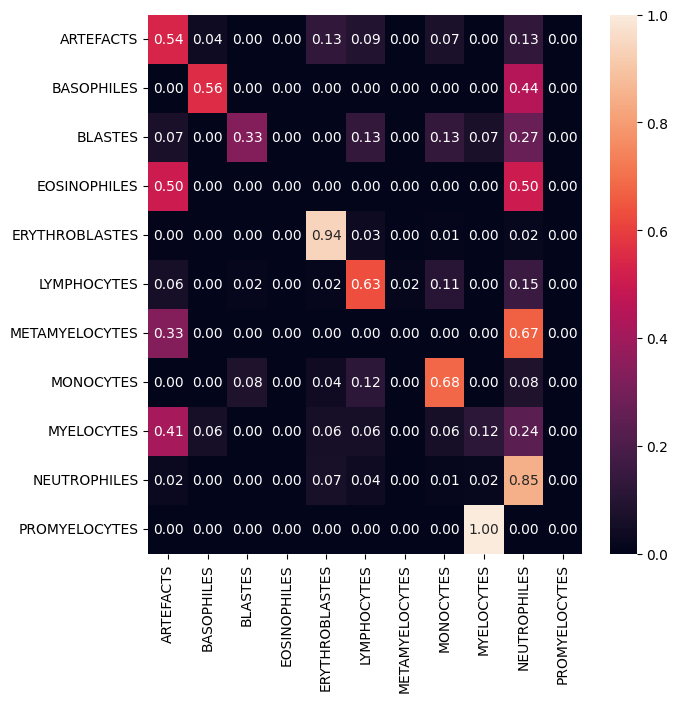

                precision    recall  f1-score   support

     ARTEFACTS       0.59      0.54      0.56        54
    BASOPHILES       0.77      0.56      0.65        18
       BLASTES       0.62      0.33      0.43        15
  EOSINOPHILES       0.00      0.00      0.00         2
ERYTHROBLASTES       0.92      0.94      0.93       250
   LYMPHOCYTES       0.62      0.63      0.63        65
METAMYELOCYTES       0.00      0.00      0.00         6
     MONOCYTES       0.49      0.68      0.57        25
    MYELOCYTES       0.25      0.12      0.16        17
  NEUTROPHILES       0.76      0.85      0.80       168
 PROMYELOCYTES       0.00      0.00      0.00         2

      accuracy                           0.77       622
     macro avg       0.46      0.42      0.43       622
  weighted avg       0.76      0.77      0.76       622



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

In [ ]:
RF_model = RandomForestClassifier(n_estimators=100, random_state=42)
RF_model.fit(X_train_scaled, y_train.values.ravel())
RF_preds = RF_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, RF_preds))
plot_confusion(RF_preds, y_test.values.ravel())

report = classification_report(y_test, RF_preds)
print(report)

# Dimensionality reduction

14) The number of features is important compared with the number of cells. Use dimensionality reduction technique such as PCA to keep only 8 principal components, and evaluate the performance of SVM and RandomForest using only these 8 features. Do you know other dimensionality reduction method and how they work?

In [ ]:
PCA = PCA(n_components=8)
X_train_pca = PCA.fit_transform(X_train_scaled)
X_test_pca = PCA.transform(X_test_scaled)

In [37]:
X_train_pca.shape

(2488, 8)

SVM with PCA Accuracy: 0.7411575562700965


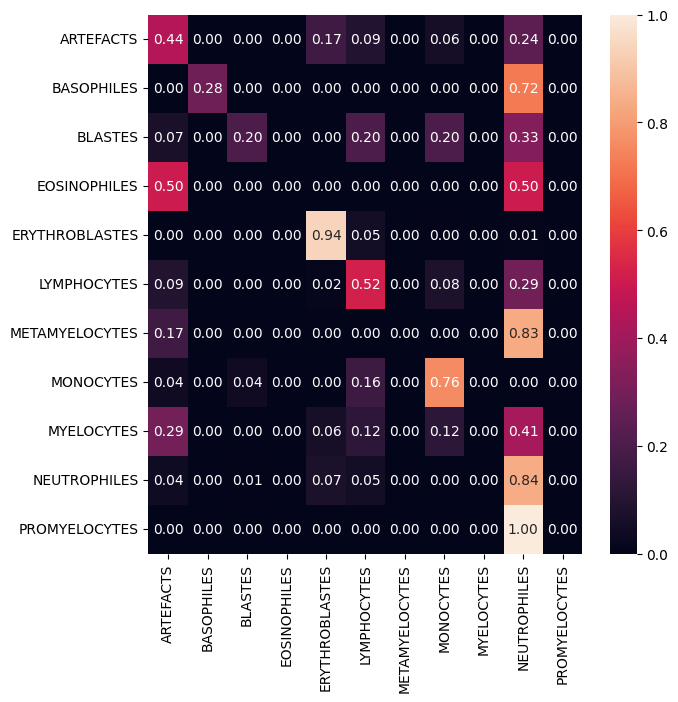

                precision    recall  f1-score   support

     ARTEFACTS       0.53      0.44      0.48        54
    BASOPHILES       1.00      0.28      0.43        18
       BLASTES       0.60      0.20      0.30        15
  EOSINOPHILES       0.00      0.00      0.00         2
ERYTHROBLASTES       0.91      0.94      0.93       250
   LYMPHOCYTES       0.50      0.52      0.51        65
METAMYELOCYTES       0.00      0.00      0.00         6
     MONOCYTES       0.58      0.76      0.66        25
    MYELOCYTES       0.00      0.00      0.00        17
  NEUTROPHILES       0.68      0.84      0.75       168
 PROMYELOCYTES       0.00      0.00      0.00         2

      accuracy                           0.74       622
     macro avg       0.44      0.36      0.37       622
  weighted avg       0.71      0.74      0.72       622



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

In [35]:
svm_model_pca = svm.SVC(kernel='rbf', gamma='scale')
svm_model_pca.fit(X_train_pca, y_train.values.ravel())
svm_preds_pca = svm_model_pca.predict(X_test_pca)
print("SVM with PCA Accuracy:", accuracy_score(y_test, svm_preds_pca))
plot_confusion(svm_preds_pca, y_test.values.ravel())
report = classification_report(y_test, svm_preds_pca)
print(report)

Random Forest with PCA Accuracy: 0.7363344051446945


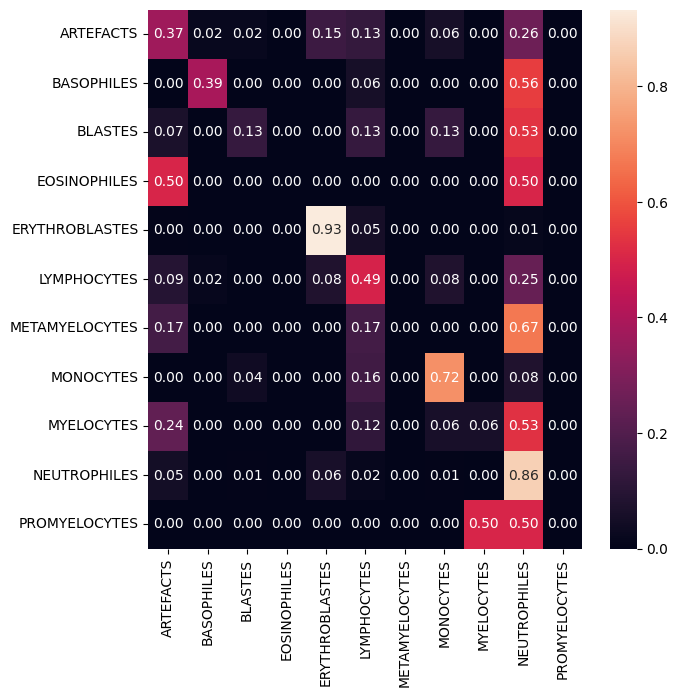

                precision    recall  f1-score   support

     ARTEFACTS       0.48      0.37      0.42        54
    BASOPHILES       0.78      0.39      0.52        18
       BLASTES       0.40      0.13      0.20        15
  EOSINOPHILES       0.00      0.00      0.00         2
ERYTHROBLASTES       0.91      0.93      0.92       250
   LYMPHOCYTES       0.49      0.49      0.49        65
METAMYELOCYTES       0.00      0.00      0.00         6
     MONOCYTES       0.60      0.72      0.65        25
    MYELOCYTES       0.50      0.06      0.11        17
  NEUTROPHILES       0.68      0.86      0.76       168
 PROMYELOCYTES       0.00      0.00      0.00         2

      accuracy                           0.74       622
     macro avg       0.44      0.36      0.37       622
  weighted avg       0.71      0.74      0.71       622



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _wa

In [36]:
rf_model_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_pca.fit(X_train_pca, y_train.values.ravel())
rf_preds_pca = rf_model_pca.predict(X_test_pca)
print("Random Forest with PCA Accuracy:", accuracy_score(y_test, rf_preds_pca))
plot_confusion(rf_preds_pca, y_test.values.ravel())
report = classification_report(y_test, rf_preds_pca)
print(report)

No net amelioration of perf...

We could try T-SNE or UMAP which are non linear. 

# Interpretation of the results

15) Are the results satisfying? Looking at the confusion matrix, what problem(s) are we encountering here?

16) Are there ways to reduce these problems?

15. The results are partially satisfying but clearly not ideal.

We observe poor performance on underrepresented classes and high performance on dominant ones, which is a typical behavior in imbalanced classification settings.

Strong confusions appear between biologically close classes, for example:

MYELOCYTES → NEUTROPHILES (~0.53)

METAMYELOCYTES → NEUTROPHILES (~0.67)

These confusions suggest that some classes are difficult to separate and that this difficulty is likely explained by biological similarity. This indicates that the model struggles with fine-grained differentiation between closely related cell types.

16. Yes, there are several ways to reduce these problems.

First, we could apply classical techniques to mitigate class imbalance, such as:
- using a class-weighted loss
- oversampling rare classes
- merging extremely rare classes if acceptable in this context

Then, we could work on improving the data representation. A naive approach would be to perform additional feature engineering, for instance by adding relationships between features (ratios, products, etc.). Another approach would be to rely on learned embeddings, using methods such as VAEs or computer vision models, and, if possible, to incorporate expert knowledge.

Finally, we could force the model to output class probabilities and analyze top-k predictions instead of relying on a single fixed output.

# Medical interpretation

17) What are the important features for prediction? How could we interpret results of the model?

In [38]:
!pip install shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.2/559.2 kB 6.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 19.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.1/31.1 MB 39.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]]te]

[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [39]:
import shap

explainer = shap.TreeExplainer(RF_model)
shap_values = explainer.shap_values(X_test_scaled)

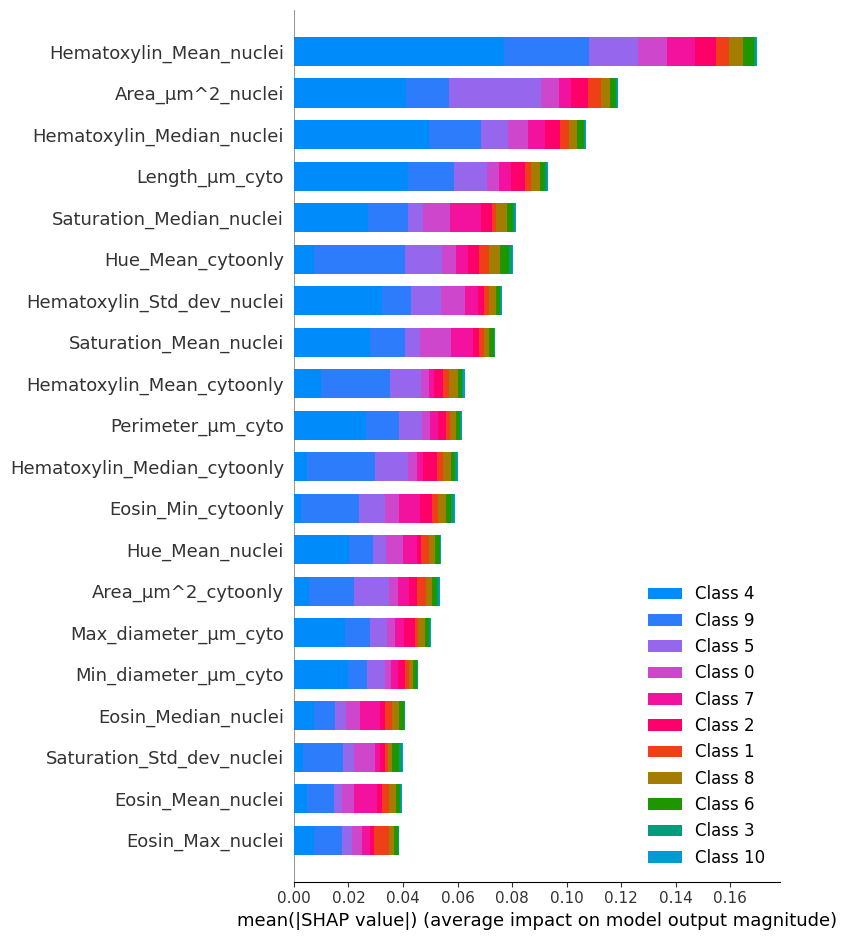

In [ ]:
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns, index=y_test.index)

shap.summary_plot(shap_values, X_test_scaled_df, plot_type="bar")
